In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import os
BASE_DIR = os.getcwd() # use this for Jupyter notebook
print(f"Base directory set to: {BASE_DIR}")

Base directory set to: c:\Users\Wang0\Documents\UNSW\Honours Thesis\code


In [2]:
# Generate a single dataframe from the signals and PnL parquet files

def month_range(start_ym: str, end_ym: str):
    # start_ym/end_ym like "2022-01"
    start = pd.Period(start_ym, freq="M")
    end = pd.Period(end_ym, freq="M")
    return [p.strftime("%Y-%m") for p in pd.period_range(start, end, freq="M")]

def load_span(data_dir: str, start_ym: str, end_ym: str,
              signal_cols=None, pnl_cols=None,
              keys=("ticker", "trade_date")):
    
    data_dir = Path(data_dir) # Allows us to use / operator for path joining

    sig_list, pnl_list = [], []
    for ym in month_range(start_ym, end_ym):
        sig_path = data_dir / f"signals_{ym}.parquet"
        pnl_path = data_dir / f"pnl_{ym}.parquet"

        # Selectively load columns if specified
        sig = pd.read_parquet(sig_path, columns=(list(keys) + (signal_cols or [])) if signal_cols else None)
        pnl = pd.read_parquet(pnl_path, columns=(list(keys) + (pnl_cols or [])) if pnl_cols else None)

        # Check for duplicate keys
        assert not sig.duplicated(list(keys)).any(), f"Duplicate keys in {sig_path.name}"
        assert not pnl.duplicated(list(keys)).any(), f"Duplicate keys in {pnl_path.name}"

        sig_list.append(sig)
        pnl_list.append(pnl)

    signals = pd.concat(sig_list, ignore_index=True)
    pnl = pd.concat(pnl_list, ignore_index=True)

    df = signals.merge(pnl, on=list(keys), how="inner", validate="one_to_one") # the rows are sorted already so use concat if merge is slow
    return df


start_month = "2023-01"
end_month   = "2024-12"
data_dir = os.path.join(BASE_DIR, "backtest_results")

df = load_span(data_dir=data_dir, start_ym=start_month, end_ym=end_month)

# Compute columns
df["pnl_norm"] = df["pnl"] / df["total_credit"]
df["win"] = (df["pnl"] > 0).astype(int)

print(f"Loaded {len(df)} rows from {start_month} to {end_month}")
print(df.head())
print(df.shape)


Loaded 3012 rows from 2023-01 to 2024-12
  ticker trade_date      iv30      rv30      ts45  iv30_rv30    avg_volume  \
0   AAPL 2023-01-03  0.426558  0.325222 -0.003180   1.311590  7.895782e+07   
1   AMZN 2023-01-03  0.519718  0.377618 -0.000282   1.376307  7.259711e+07   
2  GOOGL 2023-01-03  0.403697  0.324743 -0.000309   1.243126  2.763409e+07   
3   MSFT 2023-01-03  0.362455  0.290698 -0.001015   1.246843  2.764039e+07   
4   NVDA 2023-01-03  0.783601  0.494231  0.000865   1.585494  4.164563e+08   

   expected_move_pct expir_date   dte  ...  stock_on_expiry  strike  \
0              10.14 2023-02-03  31.0  ...           152.20   125.0   
1              12.52 2023-02-03  31.0  ...           103.39    86.0   
2               9.62 2023-02-03  31.0  ...           103.99    89.0   
3               8.72 2023-02-03  31.0  ...           252.32   240.0   
4              51.30 2023-02-03  31.0  ...            21.08   143.0   

   call_price  put_price  total_credit  gross_payoff  commissio

## Raw Analysis

In [25]:
def analysis_data(df, log = False):
    # Summarise the pnl column
    summary = df["pnl_norm"].describe()
    print("PnL Summary:")
    print(summary)

    # Additional analysis
    print("\nAdditional Analysis:")
    print(f"Total PnL: {df["pnl_norm"].sum():.2f}")
    print(f"Median PnL: {df["pnl_norm"].median():.2f}")
    print(f"Number of positive trades: {(df["pnl_norm"] > 0).sum()}")
    print(f"Number of negative trades: {(df["pnl_norm"] < 0).sum()}")
    print(f"Max PnL: {df["pnl_norm"].max():.2f}")
    print(f"Min PnL: {df["pnl_norm"].min():.2f}")

    if log:
        plt.figure(figsize=(10, 5))
        # Create two subplots: left for normal, right for log scale
        ax1 = plt.subplot(1, 2, 1)
        ax2 = plt.subplot(1, 2, 2)

        # Normal histogram
        ax1.hist(df["pnl_norm"], bins=30, color='skyblue', edgecolor='black')
        ax1.set_title("PnL Distribution (Normal)")
        ax1.set_xlabel("Normalised PnL")
        ax1.set_ylabel("Frequency")
        ax1.grid(True)

        # Logged histogram
        ax2.hist(df["pnl_norm"], bins=30, color='skyblue', edgecolor='black')
        ax2.set_title("PnL Distribution (Log Frequency)")
        ax2.set_xlabel("Normalised PnL")
        ax2.set_ylabel("Frequency")
        ax2.set_yscale("log")
        ax2.grid(True)
    else:
        plt.figure(figsize=(8, 5))
        plt.hist(df["pnl_norm"], bins=30, color='skyblue', edgecolor='black')
        plt.title("PnL Distribution")
        plt.xlabel("Normalised PnL")
        plt.ylabel("Frequency")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_pnl_over_time(df):
    plt.figure(figsize=(10, 5))
    df_sorted = df.sort_values(by="trade_date")
    plt.plot(df_sorted["trade_date"], df_sorted["pnl_norm"].cumsum(), marker='o', linestyle='-')
    plt.title("Cumulative PnL Over Time")
    plt.xlabel("Trade Date")
    plt.ylabel("Cumulative PnL")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

PnL Summary:
count    3012.000000
mean       -0.859923
std         2.595681
min       -12.037344
25%        -0.700429
50%         0.083288
75%         0.568179
max         1.000000
Name: pnl_norm, dtype: float64

Additional Analysis:
Total PnL: -2590.09
Median PnL: 0.08
Number of positive trades: 1597
Number of negative trades: 1415
Max PnL: 1.00
Min PnL: -12.04


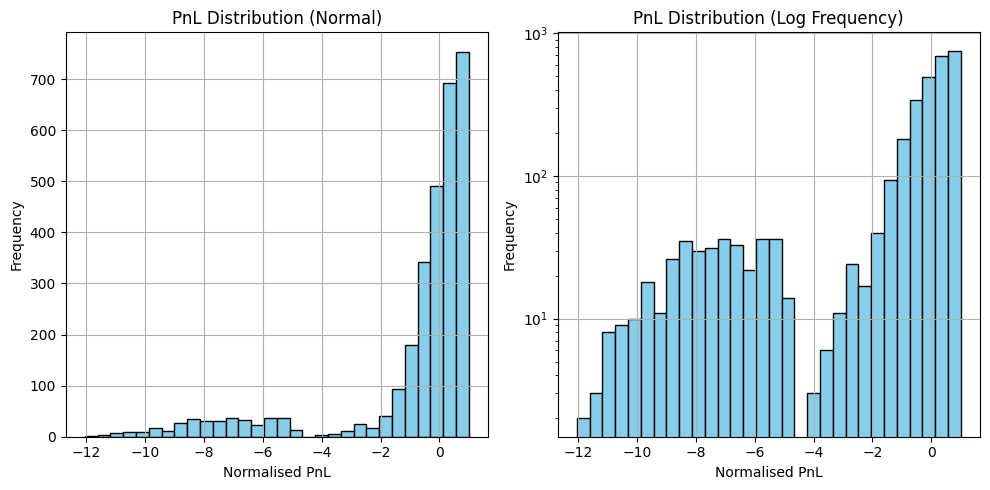

In [26]:
analysis_data(df, log=True)

## Filter Trades

PnL Summary:
count    181.000000
mean      -1.208670
std        2.578698
min       -9.032427
25%       -1.173983
50%       -0.115421
75%        0.452142
max        0.994295
Name: pnl_norm, dtype: float64

Additional Analysis:
Total PnL: -218.77
Median PnL: -0.12
Number of positive trades: 83
Number of negative trades: 98
Max PnL: 0.99
Min PnL: -9.03


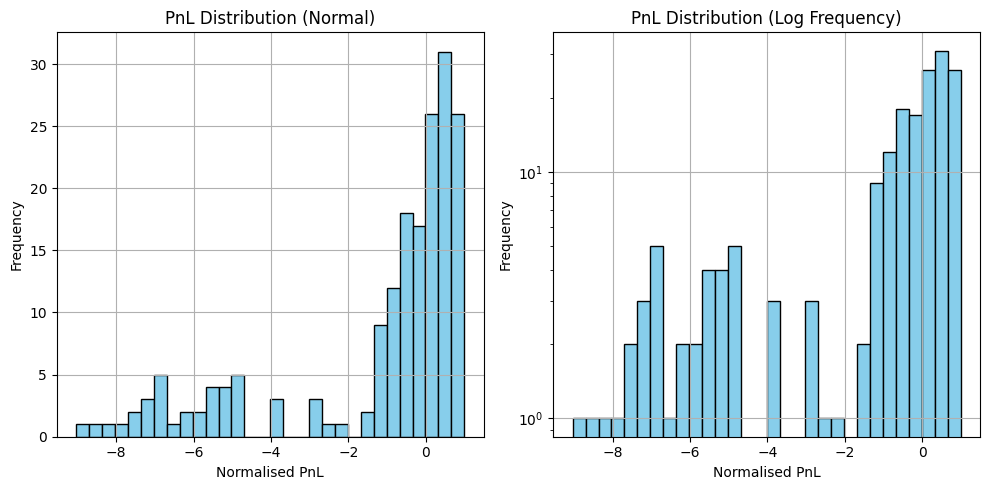

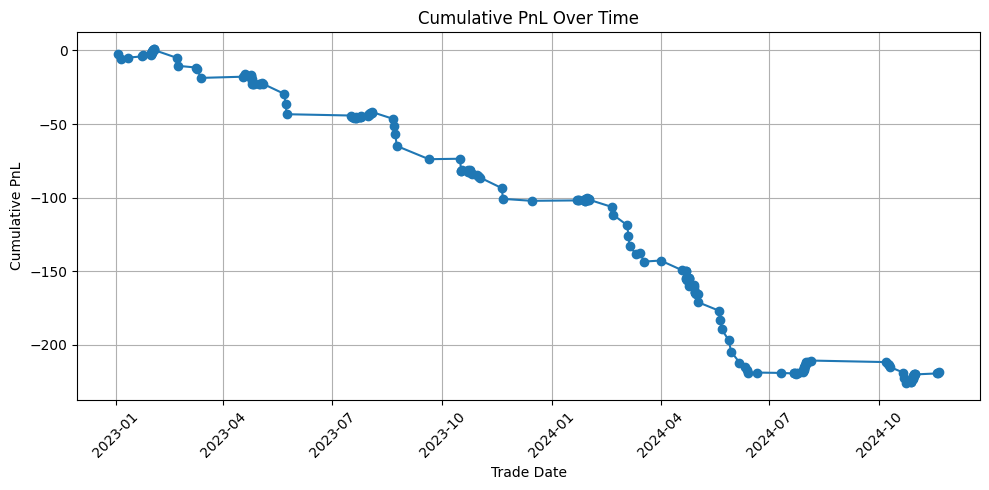

In [27]:
mask = (df["ts45"] <= -0.004) & (df["iv30_rv30"] >= 1)
filtered_df = df.loc[mask]
analysis_data(filtered_df, log=True)
plot_pnl_over_time(filtered_df)

## Average PnL for Different Tickers

In [28]:
# Calculate average PnL for each ticker
pnl_by_ticker = df.groupby("ticker")["pnl_norm"].mean()
filtered_pnl_by_ticker = filtered_df.groupby("ticker")["pnl_norm"].mean()

concat_df = pd.concat([pnl_by_ticker, filtered_pnl_by_ticker], axis=1)
concat_df.columns = ['All Trades', 'Filtered Trades']
concat_df = concat_df.sort_values(by='Filtered Trades', ascending=False)

print("Average PnL by Ticker:")
print(concat_df)

Average PnL by Ticker:
        All Trades  Filtered Trades
ticker                             
AAPL     -0.020959         0.137235
AMZN      0.121740         0.076820
GOOGL     0.087237         0.014426
MSFT      0.165532         0.011260
TSLA     -0.266419        -0.901296
NVDA     -5.246670        -5.118814


# Cross sectional checks

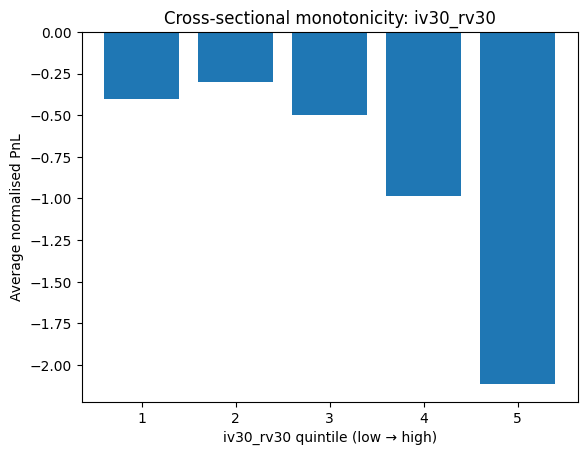

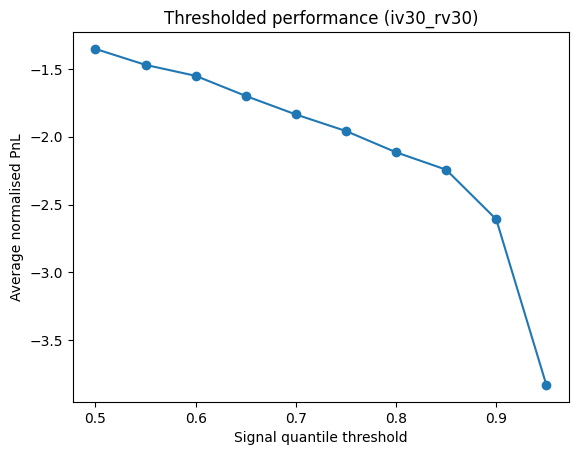

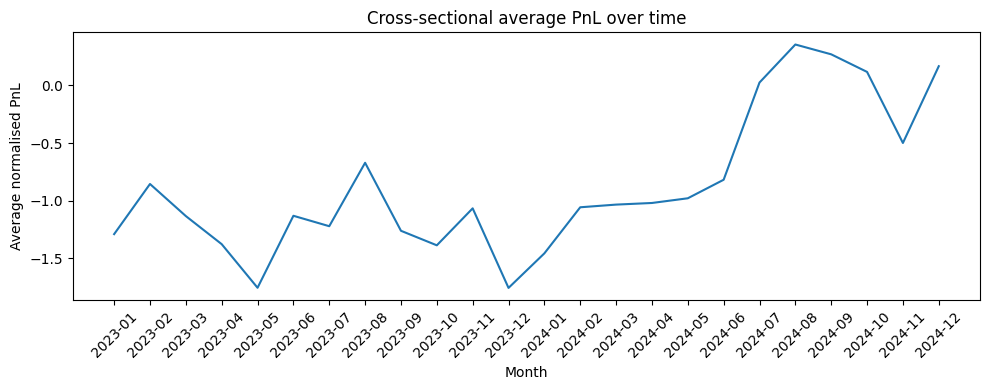

In [3]:
TARGET = "pnl_norm"
signal = "iv30_rv30"

df["signal_quintile"] = pd.qcut(df[signal], 5, labels=False) + 1
cs_quintile = (
    df.groupby("signal_quintile")[TARGET]
    .mean()
    .reset_index()
)
plt.figure()
plt.bar(cs_quintile["signal_quintile"], cs_quintile[TARGET])
plt.xlabel("iv30_rv30 quintile (low → high)")
plt.ylabel("Average normalised PnL")
plt.title("Cross-sectional monotonicity: iv30_rv30")
plt.show()


# If I only trade strong signals, doeso performance improve?
thresholds = np.linspace(0.5, 0.95, 10)
threshold_results = []
for q in thresholds:
    cutoff = df[signal].quantile(q)
    subset = df[df[signal] > cutoff]

    threshold_results.append({
        "quantile": q,
        "avg_pnl_norm": subset[TARGET].mean(),
        "win_rate": subset["win"].mean(),
        "n_trades": len(subset),
    })
threshold_df = pd.DataFrame(threshold_results)
plt.figure()
plt.plot(threshold_df["quantile"], threshold_df["avg_pnl_norm"], marker="o")
plt.xlabel("Signal quantile threshold")
plt.ylabel("Average normalised PnL")
plt.title("Thresholded performance (iv30_rv30)")
plt.show()

# Time-series cross-sectional stability (by month)
# Is the signal stable through time, or regime-dependent?

df["month"] = df["trade_date"].dt.to_period("M")
monthly_cs = (
    df.groupby("month")[TARGET]
    .mean()
    .reset_index()
)
monthly_cs["month"] = monthly_cs["month"].astype(str)
plt.figure(figsize=(10,4))
plt.plot(monthly_cs["month"], monthly_cs[TARGET])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average normalised PnL")
plt.title("Cross-sectional average PnL over time")
plt.tight_layout()
plt.show()



## Compare multiple signals side-by-side

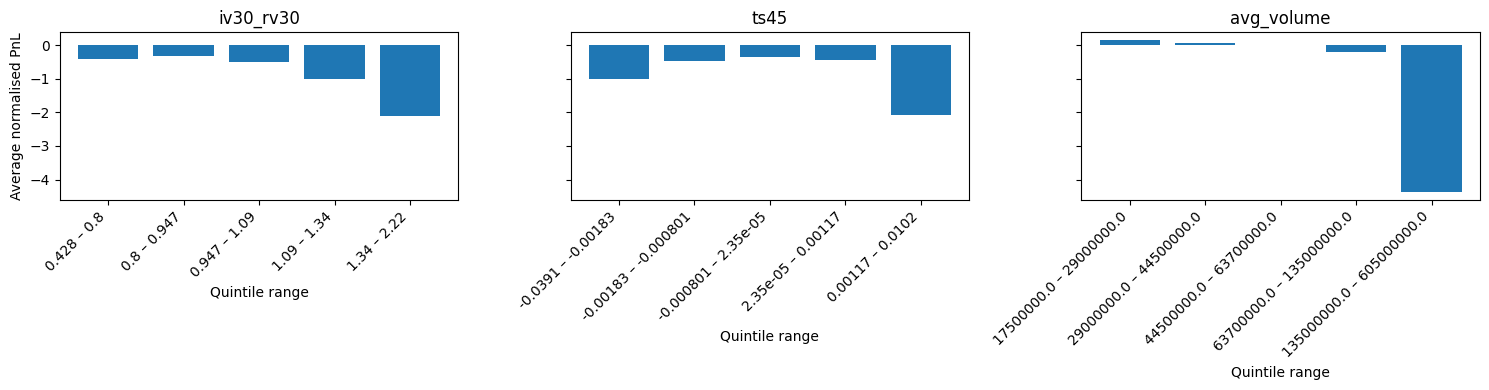

In [ ]:

signals = ["iv30_rv30", "ts45", "avg_volume"]



fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

for ax, sig in zip(axes, signals):
    # qcut with interval labels
    df["q"] = pd.qcut(df[sig], 5)

    grouped = df.groupby("q", observed=True)["pnl_norm"].mean()

    ax.bar(
        range(len(grouped)),
        grouped.values
    )
    ax.set_title(sig)
    ax.set_xlabel("Quintile range")
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels(
        [f"{interval.left:.2f} – {interval.right:.2f}" for interval in grouped.index],
        rotation=45,
        ha="right"
    )

axes[0].set_ylabel("Average normalised PnL")
plt.tight_layout()
plt.show()


## Profit with Varying Thresholds


Best (subject to min_trades filter):
  ts45 <= -0.010545  (q=0.429)
  iv30_rv30 >= 1.446931  (q=0.666)
  avg PnL = -0.7336, trades = 37


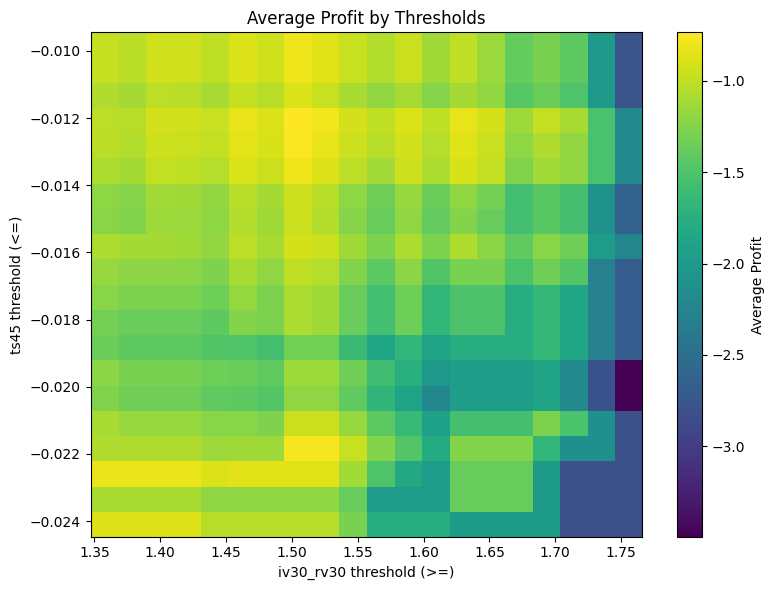

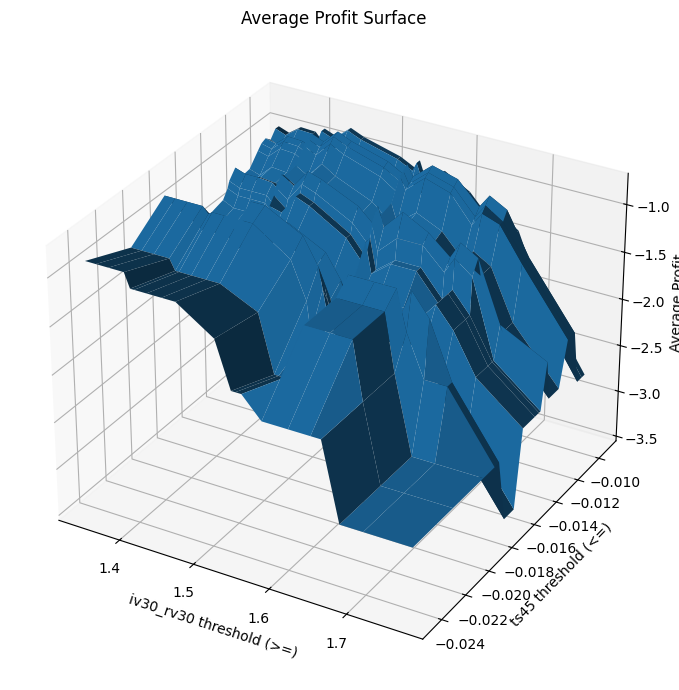

In [29]:
ts_col    = "ts45"
ratio_col = "iv30_rv30"
pnl_col   = "pnl_norm"

data = filtered_df[[ts_col, ratio_col, pnl_col]].replace([np.inf, -np.inf], np.nan).dropna() # clean data

# -----------------------
# 4) Threshold grids
#    - ts45: scan lower quantiles (more negative)
#    - ratio: scan upper quantiles (more positive)
# -----------------------
# Tweak these if you want a denser/sparser grid
q_ts  = np.linspace(0.05, 0.50, 20)   # lower quantiles for negative thresholds
q_rat = np.linspace(0.50, 0.95, 20)   # upper quantiles for positive thresholds

ts_thresholds    = np.quantile(data[ts_col], q_ts)
ratio_thresholds = np.quantile(data[ratio_col], q_rat)

# -----------------------
# 5) Compute mean PnL and trade counts per cell
# -----------------------
heat   = np.full((len(ts_thresholds), len(ratio_thresholds)), np.nan)
counts = np.zeros_like(heat, dtype=int)

for i, t_ts in enumerate(ts_thresholds):
    for j, t_rat in enumerate(ratio_thresholds):
        mask = (data[ts_col] <= t_ts) & (data[ratio_col] >= t_rat)
        sub = data.loc[mask, pnl_col]
        counts[i, j] = sub.shape[0]
        if sub.shape[0] > 0:
            heat[i, j] = sub.mean()

# -----------------------
# 6) Stability filter + best cell
# -----------------------
min_trades = max(30, int(0.001 * len(data)))  # at least 0.1% of sample or 10
best_val = np.nan
best_idx = (None, None)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        if counts[i, j] >= min_trades and not np.isnan(heat[i, j]):
            if np.isnan(best_val) or heat[i, j] > best_val:
                best_val = heat[i, j]
                best_idx = (i, j)

if best_idx[0] is not None:
    i, j = best_idx
    print("\nBest (subject to min_trades filter):")
    print(f"  ts45 <= {ts_thresholds[i]:.6f}  (q={q_ts[i]:.3f})")
    print(f"  iv30_rv30 >= {ratio_thresholds[j]:.6f}  (q={q_rat[j]:.3f})")
    print(f"  avg PnL = {heat[i, j]:.4f}, trades = {counts[i, j]}")
else:
    print("\nNo cell met the minimum trade count filter.")

# -----------------------
# 7) Save tidy grid results and a ranked top list
# -----------------------
rows = []
for i, t_ts in enumerate(ts_thresholds):
    for j, t_rat in enumerate(ratio_thresholds):
        rows.append({
            "ts45_threshold": t_ts,
            "iv30_rv30_threshold": t_rat,
            "avg_profit": heat[i, j],
            "num_trades": counts[i, j],
        })
grid_df = pd.DataFrame(rows)


top = (grid_df[grid_df["num_trades"] >= min_trades]
       .sort_values("avg_profit", ascending=False)
       .head(25)
       .reset_index(drop=True))


# Heatmap of average profit
plt.figure(figsize=(8, 6))
plt.imshow(
    heat,
    aspect='auto',
    origin='lower',
    extent=[ratio_thresholds.min(), ratio_thresholds.max(),
            ts_thresholds.min(), ts_thresholds.max()]
)
plt.colorbar(label='Average Profit')
plt.xlabel('iv30_rv30 threshold (>=)')
plt.ylabel('ts45 threshold (<=)')
plt.title('Average Profit by Thresholds')
plt.tight_layout()
plt.show()

# 3D surface plot
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
# Replace NaNs with the global nanmean just for plotting continuity
Z = np.array(heat, copy=True)
Z = np.where(np.isnan(Z), np.nanmean(Z), Z)
surf = ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True)
ax.set_xlabel('iv30_rv30 threshold (>=)')
ax.set_ylabel('ts45 threshold (<=)')
ax.set_zlabel('Average Profit')
ax.set_title('Average Profit Surface')
plt.tight_layout()
plt.show()